In [ ]:
!where python


In [ ]:

!"c:\Users\Hulk\AppData\Local\Programs\Python\Python312\python.exe" -m pip install pymupdf matplotlib ipywidgets pillow

In [ ]:
# ============================================================
# INTERACTIVE PDF BLOCK VIEWER
# Stable Matplotlib + ipywidgets design
# ============================================================

%matplotlib widget

import pymupdf
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import ipywidgets as widgets

from IPython.display import (
    display,
    Image as IPyImage,
    clear_output
)

import numpy as np


# ============================================================
# 1. OPEN PDF
# ============================================================

FILE_NAME_PAPER = "../2608.02980v1.pdf"

doc = pymupdf.open(FILE_NAME_PAPER)


# ============================================================
# 2. GLOBAL STATE
# ============================================================

fig = None
ax = None

current_page = None
current_page_number = 1

current_blocks = []
current_rectangles = []

_pick_cid = None


# ============================================================
# 3. TWO SEPARATE OUTPUT AREAS
#
# plot_output  = PDF viewer
# info_output  = selected block information
#
# We NEVER clear plot_output.
# ============================================================

plot_output = widgets.Output(
    layout=widgets.Layout(
        width="100%",
        height="900px",
        overflow="auto",
        border="1px solid #cccccc"
    )
)

info_output = widgets.Output(
    layout=widgets.Layout(
        width="100%",
        min_height="150px",
        max_height="400px",
        overflow="auto",
        border="1px solid #cccccc",
        padding="10px"
    )
)


# ============================================================
# 4. RENDER PDF
# ============================================================

def render_page(page, zoom=2.0):

    mat = pymupdf.Matrix(
        zoom,
        zoom
    )

    pix = page.get_pixmap(
        matrix=mat,
        alpha=False
    )

    img = np.frombuffer(
        pix.samples,
        dtype=np.uint8
    )

    img = img.reshape(
        pix.height,
        pix.width,
        3
    )

    return img, zoom


# ============================================================
# 5. EXTRACT PDF BLOCKS
# ============================================================

def get_blocks_with_metadata(page, zoom):

    blocks = page.get_text("blocks")

    result = []

    for block_index, b in enumerate(blocks):

        x0, y0, x1, y1, text, block_no, block_type = b

        # ----------------------------------------------------
        # Only support normal text and image blocks
        # ----------------------------------------------------

        if block_type not in (0, 1):
            continue

        # ----------------------------------------------------
        # Rectangle
        # ----------------------------------------------------

        rect = Rectangle(

            (x0 * zoom, y0 * zoom),

            (x1 - x0) * zoom,

            (y1 - y0) * zoom,

            linewidth=1.5,

            edgecolor="red",

            facecolor="none",

            picker=True
        )

        # ----------------------------------------------------
        # Store information
        # ----------------------------------------------------

        result.append({

            "rect": rect,

            "type": block_type,

            "text": text if block_type == 0 else None,

            "bbox": (
                x0,
                y0,
                x1,
                y1
            ),

            "block_index": block_index,

            "block_no": block_no,

            "page": page
        })

    return result


# ============================================================
# 6. FIND IMAGE
# ============================================================

def get_image_xref_from_block(page, bbox):

    try:

        image_rects = page.get_image_rects()

        cx = (bbox[0] + bbox[2]) / 2
        cy = (bbox[1] + bbox[3]) / 2

        for item in image_rects:

            xref = item[0]
            rect = item[1]

            if (
                rect.x0 <= cx <= rect.x1
                and
                rect.y0 <= cy <= rect.y1
            ):

                return xref

    except Exception:

        pass


    # --------------------------------------------------------
    # Fallback
    # --------------------------------------------------------

    try:

        images = page.get_images(full=True)

        if images:

            return images[0][0]

    except Exception:

        pass


    return None


# ============================================================
# 7. SHOW TEXT
#
# IMPORTANT:
# Only info_output is cleared.
# PDF viewer remains untouched.
# ============================================================

def show_text(data):

    text = data["text"]

    with info_output:

        clear_output(wait=True)

        print("=" * 70)

        print(
            f"📝 TEXT BLOCK"
        )

        print(
            f"Page: {current_page_number}"
        )

        print(
            f"Block: {data['block_index']}"
        )

        print("=" * 70)

        if text and text.strip():

            print(text.strip())

        else:

            print("[Empty text block]")

        print("=" * 70)


# ============================================================
# 8. SHOW IMAGE
# ============================================================

def show_image(data):

    with info_output:

        clear_output(wait=True)

        print("=" * 70)

        print(
            "🖼️ IMAGE BLOCK"
        )

        print(
            f"Page: {current_page_number}"
        )

        print(
            f"Block: {data['block_index']}"
        )

        print("=" * 70)


        xref = get_image_xref_from_block(
            current_page,
            data["bbox"]
        )


        if xref is None:

            print(
                "No embedded image was found."
            )

            return


        try:

            pix = pymupdf.Pixmap(
                doc,
                xref
            )

            # Convert to RGB if necessary
            if pix.n - pix.alpha > 3:

                pix = pymupdf.Pixmap(
                    pymupdf.csRGB,
                    pix
                )


            image_data = pix.tobytes(
                "png"
            )


            display(
                IPyImage(
                    data=image_data
                )
            )


            print(
                f"XREF: {xref}"
            )

            print(
                f"Image size: "
                f"{pix.width} × {pix.height}"
            )


            pix = None


        except Exception as e:

            print(
                f"Image extraction error: {e}"
            )


        print("=" * 70)


# ============================================================
# 9. CLICK HANDLER
# ============================================================

def on_pick(event):

    global current_blocks
    global current_rectangles


    # --------------------------------------------------------
    # Check page
    # --------------------------------------------------------

    if current_page is None:

        return


    # --------------------------------------------------------
    # Check selected rectangle
    # --------------------------------------------------------

    if event.artist not in current_rectangles:

        return


    # --------------------------------------------------------
    # Find block
    # --------------------------------------------------------

    index = current_rectangles.index(
        event.artist
    )

    data = current_blocks[index]


    # --------------------------------------------------------
    # TEXT
    # --------------------------------------------------------

    if data["type"] == 0:

        show_text(data)


    # --------------------------------------------------------
    # IMAGE
    # --------------------------------------------------------

    elif data["type"] == 1:

        show_image(data)


# ============================================================
# 10. UPDATE PAGE
# ============================================================

def update_page(page_number):

    global fig
    global ax

    global current_page
    global current_page_number

    global current_blocks
    global current_rectangles

    global _pick_cid


    page_index = int(page_number) - 1

    current_page_number = page_index + 1

    current_page = doc[page_index]


    # ========================================================
    # RENDER PAGE
    # ========================================================

    image, zoom = render_page(
        current_page,
        zoom=2.0
    )


    # ========================================================
    # CREATE FIGURE ONLY ONCE
    # ========================================================

    if fig is None:

        fig, ax = plt.subplots(
            figsize=(10, 14)
        )

        # ----------------------------------------------------
        # IMPORTANT:
        # Display canvas explicitly inside plot_output
        # ----------------------------------------------------

        with plot_output:

            display(fig.canvas)


    else:

        # ----------------------------------------------------
        # Do NOT create a new figure.
        # Do NOT clear notebook output.
        # Just clear the existing axes.
        # ----------------------------------------------------

        ax.clear()


    # ========================================================
    # DISPLAY PDF
    # ========================================================

    ax.imshow(
        image
    )

    ax.axis("off")


    # ========================================================
    # EXTRACT BLOCKS
    # ========================================================

    blocks = get_blocks_with_metadata(
        current_page,
        zoom
    )

    current_blocks = blocks

    current_rectangles = []


    # ========================================================
    # DRAW BLOCK RECTANGLES
    # ========================================================

    for data in blocks:

        rect = data["rect"]

        ax.add_patch(
            rect
        )

        current_rectangles.append(
            rect
        )


    # ========================================================
    # TITLE
    # ========================================================

    ax.set_title(
        f"Page {current_page_number} "
        f"— Click a block",
        fontsize=14
    )


    # ========================================================
    # DISCONNECT OLD EVENT
    # ========================================================

    if _pick_cid is not None:

        try:

            fig.canvas.mpl_disconnect(
                _pick_cid
            )

        except Exception:

            pass


    # ========================================================
    # CONNECT EXACTLY ONE EVENT
    # ========================================================

    _pick_cid = fig.canvas.mpl_connect(
        "pick_event",
        on_pick
    )


    # ========================================================
    # UPDATE PDF CANVAS
    # ========================================================

    fig.canvas.draw_idle()


    # ========================================================
    # UPDATE INFORMATION PANEL
    #
    # This is the ONLY output that gets cleared.
    # ========================================================

    with info_output:

        clear_output(wait=True)

        print(
            f"📄 Page {current_page_number}"
        )

        print()

        print(
            "Click a red rectangle to inspect text."
        )

        print(
            "Click an image rectangle to inspect image."
        )


# ============================================================
# 11. PAGE SLIDER
# ============================================================

slider = widgets.IntSlider(

    value=1,

    min=1,

    max=doc.page_count,

    step=1,

    description="Page:",

    continuous_update=False,

    layout=widgets.Layout(
        width="100%"
    )
)


# ============================================================
# 12. SLIDER CALLBACK
# ============================================================

def slider_changed(change):

    if change["name"] != "value":

        return

    update_page(
        change["new"]
    )


slider.observe(
    slider_changed,
    names="value"
)


# ============================================================
# 13. HEADER
# ============================================================

header = widgets.HTML(
    value="""
    <h3 style="margin:5px 0;">
        📚 Interactive PDF Research Reader
    </h3>
    """
)


# ============================================================
# 14. COMPLETE APPLICATION UI
# ============================================================

application = widgets.VBox(

    [

        header,

        slider,

        plot_output,

        info_output

    ],

    layout=widgets.Layout(
        width="100%"
    )
)


# ============================================================
# 15. DISPLAY APPLICATION
# ============================================================

display(application)


# ============================================================
# 16. LOAD FIRST PAGE
# ============================================================

update_page(1)


# ============================================================
# IMPORTANT:
#
# NEVER run:
#
#     doc.close()
#
# while the application is running.
# ============================================================

In [ ]:
# ============================================================
# INTERACTIVE PDF RESEARCH READER + LOCAL OLLAMA
# ============================================================
#
# Features:
#   1. Display PDF pages with clickable text (red) and image (blue) blocks
#   2. Click text → send selected text to Ollama (explain)
#   3. Click image → send image to vision model (analyze)
#   4. Page slider
#   5. Ollama streaming with thinking/reasoning support
#   6. PDF remains visible, only AI output updates
#   7. Manual click detection (no pick_event errors)
#   8. Correct coordinate mapping (no y-flip)
#
# Requirements:
#   pip install pymupdf matplotlib ipympl ipywidgets requests pillow
#
# Ollama must be running: ollama serve
#
# ============================================================

%matplotlib widget

import os, io, time, json, base64, requests, traceback
import fitz
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output
from PIL import Image

# ------------------------------------------------------------
# USER CONFIGURATION
# ------------------------------------------------------------
FILE_NAME_PAPER = "../2608.02980v1.pdf"          # change to your PDF
CHAT_MODEL = "qwen2:0.5b"                        # default text model
OLLAMA_URL = "http://localhost:11434/api/chat"
PDF_ZOOM = 1.5
CHAT_HEIGHT = "500px"

# ------------------------------------------------------------
# CHECK PDF
# ------------------------------------------------------------
if not os.path.exists(FILE_NAME_PAPER):
    raise FileNotFoundError(f"PDF not found: {os.path.abspath(FILE_NAME_PAPER)}")

doc = fitz.open(FILE_NAME_PAPER)
TOTAL_PAGES = len(doc)
print(f"✅ PDF loaded: {os.path.basename(FILE_NAME_PAPER)} ({TOTAL_PAGES} pages)")

# ------------------------------------------------------------
# GLOBAL STATE
# ------------------------------------------------------------
current_page_number = 1
current_blocks = []
fig = None
ax = None
chat_running = False

# ------------------------------------------------------------
# OUTPUT CONTAINERS (PDF and AI are separate)
# ------------------------------------------------------------
pdf_output = widgets.Output(layout=widgets.Layout(width="900px", height="850px",
                                                  border="1px solid #999", overflow="auto"))
chat_output = widgets.Output(layout=widgets.Layout(width="900px", height=CHAT_HEIGHT,
                                                   border="1px solid #999", overflow="auto"))

# ------------------------------------------------------------
# MODEL FEATURE DETECTION
# ------------------------------------------------------------
def get_model_features(model_name):
    name = model_name.lower()
    vision_keywords = ["vision", "vl", "llava", "qwen2.5vl", "qwen3-vl", "llama3.2-vision",
                       "gemma3", "ministral", "mistral-small3.1"]
    thinking_keywords = ["thinking", "reasoning", "deepseek-r1", "phi4-reasoning", "nemotron"]
    return {
        "vision": any(k in name for k in vision_keywords),
        "thinking": any(k in name for k in thinking_keywords)
    }

# ------------------------------------------------------------
# IMAGE TO BASE64
# ------------------------------------------------------------
def image_bytes_to_base64(img_bytes):
    return base64.b64encode(img_bytes).decode("utf-8")

# ------------------------------------------------------------
# OLLAMA CHAT (streaming)
# ------------------------------------------------------------
def chat_aware(prompt, model=None, image_b64=None):
    global chat_running
    if model is None: model = CHAT_MODEL
    features = get_model_features(model)
    chat_running = True

    with chat_output:
        clear_output(wait=True)
        display(Markdown(f"### 🤖 Ollama\n**Model:** `{model}`\n**Vision:** `{'✅' if features['vision'] else '❌'}`\n**Thinking:** `{'✅' if features['thinking'] else '❌'}`\n---\n⏳ Generating..."))

    messages = [{"role": "user", "content": prompt}]
    if image_b64 is not None:
        if not features["vision"]:
            with chat_output:
                clear_output(wait=True)
                display(Markdown(f"### ⚠️ Vision model required\n`{model}` does not support images. Use a vision model."))
            chat_running = False
            return
        messages[0]["images"] = [image_b64]

    payload = {"model": model, "messages": messages, "stream": True}
    start_time = time.time()
    thinking_text = ""
    answer_text = ""

    try:
        response = requests.post(OLLAMA_URL, json=payload, stream=True, timeout=600)
        response.raise_for_status()

        for line in response.iter_lines():
            if not line: continue
            try:
                data = json.loads(line.decode("utf-8"))
            except:
                continue
            message = data.get("message", {})
            thinking_piece = message.get("thinking", "")
            if thinking_piece: thinking_text += thinking_piece
            content_piece = message.get("content", "")
            if content_piece: answer_text += content_piece

            with chat_output:
                clear_output(wait=True)
                md = f"### 🤖 `{model}`\n**Elapsed:** `{time.time()-start_time:.2f} sec`\n---\n"
                if thinking_text:
                    md += f"<details><summary>🧠 Thinking</summary>{thinking_text}</details>\n---\n"
                md += f"### 💡 Answer\n{answer_text}"
                display(Markdown(md))

            if data.get("done", False):
                break

        with chat_output:
            clear_output(wait=True)
            md = f"### 🤖 `{model}`\n**Time:** `{time.time()-start_time:.2f} sec`\n---\n"
            if thinking_text:
                md += f"<details><summary>🧠 Thinking</summary>{thinking_text}</details>\n---\n"
            md += f"### 💡 Answer\n{answer_text}"
            display(Markdown(md))

    except Exception as e:
        with chat_output:
            clear_output(wait=True)
            display(Markdown(f"### ❌ Error\n```text\n{type(e).__name__}: {e}\n```"))
            traceback.print_exc()
    finally:
        chat_running = False

# ------------------------------------------------------------
# EXTRACT PDF BLOCKS (text + image) using get_text("dict")
# ------------------------------------------------------------
def get_pdf_blocks(page):
    data = page.get_text("dict")
    blocks = []
    for idx, block in enumerate(data.get("blocks", [])):
        bbox = block.get("bbox")
        if not bbox: continue
        typ = block.get("type")
        if typ == 0:   # text
            text_parts = []
            for line in block.get("lines", []):
                for span in line.get("spans", []):
                    t = span.get("text", "")
                    if t: text_parts.append(t)
            text = " ".join(text_parts).strip()
            if text:
                blocks.append({"type": "text", "bbox": bbox, "text": text, "block_index": idx})
        elif typ == 1: # image
            img_bytes = block.get("image")
            if img_bytes:
                blocks.append({"type": "image", "bbox": bbox, "image": img_bytes,
                               "block_index": idx})
    return blocks

# ------------------------------------------------------------
# COORDINATE CONVERSION (PDF coords → display coords, no flip)
# Since imshow(origin='upper'), y increases downward as in PDF.
# ------------------------------------------------------------
def pdf_bbox_to_display_bbox(bbox, zoom):
    x0, y0, x1, y1 = bbox
    return (x0*zoom, y0*zoom, (x1-x0)*zoom, (y1-y0)*zoom)

# ------------------------------------------------------------
# PROMPT BUILDERS
# ------------------------------------------------------------
def create_text_prompt(text, page_number):
    return f"""
You are helping me understand a research paper. I clicked a text block from page {page_number}.

Explain the selected text clearly. Structure your answer:
1. 📌 What the paragraph says
2. 🧠 Simple explanation
3. 🔬 Technical meaning
4. 📐 Explain equations/concepts
5. 🧩 Important terminology
6. 💡 Why important
7. 🔗 How it connects to the paper
8. 📝 Give a small example if useful

Selected text:
---
{text}
---
"""

def create_image_prompt(page_number):
    return f"""
You are helping me understand a research paper. I clicked an image/figure from page {page_number}.

Analyze the image. Explain:
1. 🖼️ What is shown?
2. 🧩 Major components
3. ➡️ Arrows and flow
4. 📦 Each block/module
5. 📐 Axes, plots, equations
6. 🔬 Technical architecture
7. 🧠 Simple language
8. 🔗 How it relates to the paper
9. 💡 Main idea the authors want to convey
10. 📝 Give a simple example/analogy if useful.

Do not invent information not visible. If text is unreadable, say so.
"""

# ------------------------------------------------------------
# CLICK HANDLERS
# ------------------------------------------------------------
def handle_text_block(block):
    text = block["text"]
    pnum = current_page_number
    with chat_output:
        clear_output(wait=True)
        display(Markdown(f"## 📄 Selected Text\n**Page:** `{pnum}`\n---\n{text}\n---\n⏳ Sending to Ollama..."))
    chat_aware(create_text_prompt(text, pnum), model=model_text.value)

def handle_image_block(block):
    pnum = current_page_number
    model = model_text.value
    if not get_model_features(model)["vision"]:
        with chat_output:
            clear_output(wait=True)
            display(Markdown(f"## 🖼️ Image selected\n**Page:** `{pnum}`\n### ⚠️ `{model}` is not a vision model. Select a vision model."))
        return
    img_bytes = block.get("image")
    if not img_bytes:
        with chat_output:
            clear_output(wait=True)
            display(Markdown("### ❌ Could not extract image."))
        return
    image_b64 = image_bytes_to_base64(img_bytes)
    # show image preview
    try:
        im = Image.open(io.BytesIO(img_bytes))
        with chat_output:
            clear_output(wait=True)
            display(Markdown(f"## 🖼️ Selected Figure\n**Page:** `{pnum}`\n**Model:** `{model}`\n⏳ Sending to Ollama..."))
            display(im)
    except:
        pass
    chat_aware(create_image_prompt(pnum), model=model, image_b64=image_b64)

# ------------------------------------------------------------
# MOUSE CLICK (manual hit test)
# ------------------------------------------------------------
def on_mouse_click(event):
    if event.inaxes != ax or event.xdata is None or event.ydata is None:
        return
    if ax is None:
        return
    click_x, click_y = event.xdata, event.ydata
    zoom = PDF_ZOOM
    for block in current_blocks:
        x, y, w, h = pdf_bbox_to_display_bbox(block["bbox"], zoom)
        if x <= click_x <= x+w and y <= click_y <= y+h:
            if block["type"] == "text":
                handle_text_block(block)
            else:
                handle_image_block(block)
            return

# ------------------------------------------------------------
# RENDER PAGE
# ------------------------------------------------------------
def render_page(page_number):
    global fig, ax, current_blocks, current_page_number
    current_page_number = page_number
    page = doc[page_number-1]
    current_blocks = get_pdf_blocks(page)

    zoom = PDF_ZOOM
    matrix = fitz.Matrix(zoom, zoom)
    pix = page.get_pixmap(matrix=matrix, alpha=False)
    img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)

    if fig is None:
        fig, ax = plt.subplots(figsize=(10, 13))
        fig.canvas.mpl_connect("button_press_event", on_mouse_click)
    else:
        ax.clear()

    ax.imshow(img, origin="upper")
    ax.set_xlim(0, pix.width)
    ax.set_ylim(pix.height, 0)   # keep origin upper
    ax.axis("off")
    ax.set_title(f"📄 Page {page_number} / {TOTAL_PAGES}", fontsize=14)

    # Draw rectangles – now coordinates are direct scaled values
    for block in current_blocks:
        x, y, w, h = pdf_bbox_to_display_bbox(block["bbox"], zoom)
        color = "red" if block["type"] == "text" else "blue"
        alpha = 0.35 if block["type"] == "text" else 0.6
        lw = 1.0 if block["type"] == "text" else 2.0
        rect = patches.Rectangle((x, y), w, h, fill=False,
                                 linewidth=lw, edgecolor=color, alpha=alpha)
        ax.add_patch(rect)

    fig.canvas.draw_idle()

# ------------------------------------------------------------
# UPDATE PAGE (slider callback)
# ------------------------------------------------------------
def update_page(change=None):
    pnum = change["new"] if change else page_slider.value
    render_page(int(pnum))
    page_status.value = f"<b>📄 Page {pnum} / {TOTAL_PAGES}</b>"

# ------------------------------------------------------------
# WIDGETS
# ------------------------------------------------------------
page_slider = widgets.IntSlider(value=1, min=1, max=TOTAL_PAGES, step=1,
                                description="Page:", continuous_update=False,
                                layout=widgets.Layout(width="700px"))
page_slider.observe(update_page, names="value")

model_text = widgets.Text(value=CHAT_MODEL, description="Ollama:",
                          layout=widgets.Layout(width="700px"))

def update_model_info(change=None):
    m = model_text.value
    f = get_model_features(m)
    model_info.value = f"<b>Model:</b> {m} &nbsp;&nbsp; <b>{'✅ Vision' if f['vision'] else '❌ Text only'}</b> &nbsp;&nbsp; <b>{'🧠 Thinking' if f['thinking'] else '💬 Normal'}</b>"
model_text.observe(update_model_info, names="value")
model_info = widgets.HTML()

page_status = widgets.HTML(value="<b>📄 Page 1</b>")

instructions = widgets.HTML("""
<div style="padding:10px; border:1px solid #aaa; border-radius:6px; margin-bottom:10px;">
<b>🖱️ How to use:</b>
<ul>
<li><b>Red rectangle</b> → click to explain text</li>
<li><b>Blue rectangle</b> → click to analyze figure (vision model required)</li>
<li>Change Ollama model above</li>
<li>Use slider to navigate</li>
</ul>
</div>
""")

pdf_header = widgets.HTML("<h2>📚 Interactive Research Paper Reader</h2>")
ai_header = widgets.HTML("<h2>🤖 AI Research Assistant</h2>")

controls = widgets.VBox([page_slider, model_text, model_info, page_status],
                        layout=widgets.Layout(padding="5px"))

application = widgets.VBox([
    pdf_header, instructions, controls,
    widgets.HTML("<h3>📄 PDF</h3>"), pdf_output,
    ai_header, chat_output
], layout=widgets.Layout(width="950px"))

# ------------------------------------------------------------
# DISPLAY AND INITIALIZE
# ------------------------------------------------------------
display(application)

# Render first page
render_page(1)

# Show canvas in the PDF output
with pdf_output:
    clear_output(wait=True)
    display(fig.canvas)

# Update UI
update_model_info()
page_status.value = f"<b>📄 Page 1 / {TOTAL_PAGES}</b>"

print("✅ Interactive PDF reader ready.")
print("🖱️ Click a red text block or blue image block.")

In [ ]:
# ============================================================
# INTERACTIVE PDF RESEARCH READER + LOCAL OLLAMA
# ============================================================
#
# Super UI with:
#   - Dropdown to select Ollama model (auto‑populated)
#   - Refresh models button
#   - Model info display (vision/thinking capabilities)
#   - Clickable text (red) and image (blue) blocks
#   - Page slider
#   - Separate PDF and AI output panels
#   - No coordinate flipping
#   - Manual click detection
#
# Requirements:
#   pip install pymupdf matplotlib ipympl ipywidgets requests pillow
#
# Ollama must be running: ollama serve
#
# ============================================================

%matplotlib widget

import os, io, time, json, base64, requests, traceback
import fitz
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output
from PIL import Image

# ------------------------------------------------------------
# USER CONFIGURATION
# ------------------------------------------------------------
FILE_NAME_PAPER = "../2608.02980v1.pdf"          # change to your PDF
DEFAULT_MODEL = "qwen2:0.5b"
OLLAMA_URL = "http://localhost:11434"
PDF_ZOOM = 1.5
CHAT_HEIGHT = "500px"

# ------------------------------------------------------------
# CHECK PDF
# ------------------------------------------------------------
if not os.path.exists(FILE_NAME_PAPER):
    raise FileNotFoundError(f"PDF not found: {os.path.abspath(FILE_NAME_PAPER)}")

doc = fitz.open(FILE_NAME_PAPER)
TOTAL_PAGES = len(doc)
print(f"✅ PDF loaded: {os.path.basename(FILE_NAME_PAPER)} ({TOTAL_PAGES} pages)")

# ------------------------------------------------------------
# GLOBAL STATE
# ------------------------------------------------------------
current_page_number = 1
current_blocks = []
fig = None
ax = None
chat_running = False

# ------------------------------------------------------------
# OUTPUT CONTAINERS (PDF and AI are separate)
# ------------------------------------------------------------
pdf_output = widgets.Output(layout=widgets.Layout(width="900px", height="850px",
                                                  border="1px solid #999", overflow="auto"))
chat_output = widgets.Output(layout=widgets.Layout(width="900px", height=CHAT_HEIGHT,
                                                   border="1px solid #999", overflow="auto"))

# ------------------------------------------------------------
# MODEL FEATURE DETECTION
# ------------------------------------------------------------
def get_model_features(model_name):
    name = model_name.lower()
    vision_keywords = ["vision", "vl", "llava", "qwen2.5vl", "qwen3-vl", "llama3.2-vision",
                       "gemma3", "ministral", "mistral-small3.1"]
    thinking_keywords = ["thinking", "reasoning", "deepseek-r1", "phi4-reasoning", "nemotron"]
    return {
        "vision": any(k in name for k in vision_keywords),
        "thinking": any(k in name for k in thinking_keywords)
    }

# ------------------------------------------------------------
# FETCH OLLAMA MODELS
# ------------------------------------------------------------
def fetch_ollama_models():
    try:
        resp = requests.get(f"{OLLAMA_URL}/api/tags", timeout=5)
        if resp.status_code == 200:
            data = resp.json()
            models = [m["name"] for m in data.get("models", [])]
            if models:
                return models
        return []
    except:
        return []

# ------------------------------------------------------------
# IMAGE TO BASE64
# ------------------------------------------------------------
def image_bytes_to_base64(img_bytes):
    return base64.b64encode(img_bytes).decode("utf-8")

# ------------------------------------------------------------
# OLLAMA CHAT (streaming)
# ------------------------------------------------------------
def chat_aware(prompt, model=None, image_b64=None):
    global chat_running
    if model is None:
        model = model_dropdown.value if model_dropdown.value else DEFAULT_MODEL
    features = get_model_features(model)
    chat_running = True

    with chat_output:
        clear_output(wait=True)
        display(Markdown(f"### 🤖 Ollama\n**Model:** `{model}`\n**Vision:** `{'✅' if features['vision'] else '❌'}`\n**Thinking:** `{'✅' if features['thinking'] else '❌'}`\n---\n⏳ Generating..."))

    messages = [{"role": "user", "content": prompt}]
    if image_b64 is not None:
        if not features["vision"]:
            with chat_output:
                clear_output(wait=True)
                display(Markdown(f"### ⚠️ Vision model required\n`{model}` does not support images. Use a vision model."))
            chat_running = False
            return
        messages[0]["images"] = [image_b64]

    payload = {"model": model, "messages": messages, "stream": True}
    start_time = time.time()
    thinking_text = ""
    answer_text = ""

    try:
        response = requests.post(f"{OLLAMA_URL}/api/chat", json=payload, stream=True, timeout=600)
        response.raise_for_status()

        for line in response.iter_lines():
            if not line: continue
            try:
                data = json.loads(line.decode("utf-8"))
            except:
                continue
            message = data.get("message", {})
            thinking_piece = message.get("thinking", "")
            if thinking_piece: thinking_text += thinking_piece
            content_piece = message.get("content", "")
            if content_piece: answer_text += content_piece

            with chat_output:
                clear_output(wait=True)
                md = f"### 🤖 `{model}`\n**Elapsed:** `{time.time()-start_time:.2f} sec`\n---\n"
                if thinking_text:
                    md += f"<details><summary>🧠 Thinking</summary>{thinking_text}</details>\n---\n"
                md += f"### 💡 Answer\n{answer_text}"
                display(Markdown(md))

            if data.get("done", False):
                break

        with chat_output:
            clear_output(wait=True)
            md = f"### 🤖 `{model}`\n**Time:** `{time.time()-start_time:.2f} sec`\n---\n"
            if thinking_text:
                md += f"<details><summary>🧠 Thinking</summary>{thinking_text}</details>\n---\n"
            md += f"### 💡 Answer\n{answer_text}"
            display(Markdown(md))

    except Exception as e:
        with chat_output:
            clear_output(wait=True)
            display(Markdown(f"### ❌ Error\n```text\n{type(e).__name__}: {e}\n```"))
            traceback.print_exc()
    finally:
        chat_running = False

# ------------------------------------------------------------
# EXTRACT PDF BLOCKS (text + image) using get_text("dict")
# ------------------------------------------------------------
def get_pdf_blocks(page):
    data = page.get_text("dict")
    blocks = []
    for idx, block in enumerate(data.get("blocks", [])):
        bbox = block.get("bbox")
        if not bbox: continue
        typ = block.get("type")
        if typ == 0:   # text
            text_parts = []
            for line in block.get("lines", []):
                for span in line.get("spans", []):
                    t = span.get("text", "")
                    if t: text_parts.append(t)
            text = " ".join(text_parts).strip()
            if text:
                blocks.append({"type": "text", "bbox": bbox, "text": text, "block_index": idx})
        elif typ == 1: # image
            img_bytes = block.get("image")
            if img_bytes:
                blocks.append({"type": "image", "bbox": bbox, "image": img_bytes,
                               "block_index": idx})
    return blocks

# ------------------------------------------------------------
# COORDINATE CONVERSION (PDF coords → display coords, no flip)
# Since imshow(origin='upper'), y increases downward as in PDF.
# ------------------------------------------------------------
def pdf_bbox_to_display_bbox(bbox, zoom):
    x0, y0, x1, y1 = bbox
    return (x0*zoom, y0*zoom, (x1-x0)*zoom, (y1-y0)*zoom)

# ------------------------------------------------------------
# PROMPT BUILDERS
# ------------------------------------------------------------
def create_text_prompt(text, page_number):
    return f"""
You are helping me understand a research paper. I clicked a text block from page {page_number}.

Explain the selected text clearly. Structure your answer:
1. 📌 What the paragraph says
2. 🧠 Simple explanation
3. 🔬 Technical meaning
4. 📐 Explain equations/concepts
5. 🧩 Important terminology
6. 💡 Why important
7. 🔗 How it connects to the paper
8. 📝 Give a small example if useful

Selected text:
---
{text}
---
"""

def create_image_prompt(page_number):
    return f"""
You are helping me understand a research paper. I clicked an image/figure from page {page_number}.

Analyze the image. Explain:
1. 🖼️ What is shown?
2. 🧩 Major components
3. ➡️ Arrows and flow
4. 📦 Each block/module
5. 📐 Axes, plots, equations
6. 🔬 Technical architecture
7. 🧠 Simple language
8. 🔗 How it relates to the paper
9. 💡 Main idea the authors want to convey
10. 📝 Give a simple example/analogy if useful.

Do not invent information not visible. If text is unreadable, say so.
"""

# ------------------------------------------------------------
# CLICK HANDLERS
# ------------------------------------------------------------
def handle_text_block(block):
    text = block["text"]
    pnum = current_page_number
    with chat_output:
        clear_output(wait=True)
        display(Markdown(f"## 📄 Selected Text\n**Page:** `{pnum}`\n---\n{text}\n---\n⏳ Sending to Ollama..."))
    chat_aware(create_text_prompt(text, pnum), model=model_dropdown.value)

def handle_image_block(block):
    pnum = current_page_number
    model = model_dropdown.value
    if not get_model_features(model)["vision"]:
        with chat_output:
            clear_output(wait=True)
            display(Markdown(f"## 🖼️ Image selected\n**Page:** `{pnum}`\n### ⚠️ `{model}` is not a vision model. Select a vision model."))
        return
    img_bytes = block.get("image")
    if not img_bytes:
        with chat_output:
            clear_output(wait=True)
            display(Markdown("### ❌ Could not extract image."))
        return
    image_b64 = image_bytes_to_base64(img_bytes)
    # show image preview
    try:
        im = Image.open(io.BytesIO(img_bytes))
        with chat_output:
            clear_output(wait=True)
            display(Markdown(f"## 🖼️ Selected Figure\n**Page:** `{pnum}`\n**Model:** `{model}`\n⏳ Sending to Ollama..."))
            display(im)
    except:
        pass
    chat_aware(create_image_prompt(pnum), model=model, image_b64=image_b64)

# ------------------------------------------------------------
# MOUSE CLICK (manual hit test)
# ------------------------------------------------------------
def on_mouse_click(event):
    if event.inaxes != ax or event.xdata is None or event.ydata is None:
        return
    if ax is None:
        return
    click_x, click_y = event.xdata, event.ydata
    zoom = PDF_ZOOM
    for block in current_blocks:
        x, y, w, h = pdf_bbox_to_display_bbox(block["bbox"], zoom)
        if x <= click_x <= x+w and y <= click_y <= y+h:
            if block["type"] == "text":
                handle_text_block(block)
            else:
                handle_image_block(block)
            return

# ------------------------------------------------------------
# RENDER PAGE
# ------------------------------------------------------------
def render_page(page_number):
    global fig, ax, current_blocks, current_page_number
    current_page_number = page_number
    page = doc[page_number-1]
    current_blocks = get_pdf_blocks(page)

    zoom = PDF_ZOOM
    matrix = fitz.Matrix(zoom, zoom)
    pix = page.get_pixmap(matrix=matrix, alpha=False)
    img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)

    if fig is None:
        fig, ax = plt.subplots(figsize=(10, 13))
        fig.canvas.mpl_connect("button_press_event", on_mouse_click)
    else:
        ax.clear()

    ax.imshow(img, origin="upper")
    ax.set_xlim(0, pix.width)
    ax.set_ylim(pix.height, 0)
    ax.axis("off")
    ax.set_title(f"📄 Page {page_number} / {TOTAL_PAGES}", fontsize=14)

    for block in current_blocks:
        x, y, w, h = pdf_bbox_to_display_bbox(block["bbox"], zoom)
        color = "red" if block["type"] == "text" else "blue"
        alpha = 0.35 if block["type"] == "text" else 0.6
        lw = 1.0 if block["type"] == "text" else 2.0
        rect = patches.Rectangle((x, y), w, h, fill=False,
                                 linewidth=lw, edgecolor=color, alpha=alpha)
        ax.add_patch(rect)

    fig.canvas.draw_idle()

# ------------------------------------------------------------
# UPDATE PAGE (slider callback)
# ------------------------------------------------------------
def update_page(change=None):
    pnum = change["new"] if change else page_slider.value
    render_page(int(pnum))
    page_status.value = f"<b>📄 Page {pnum} / {TOTAL_PAGES}</b>"

# ------------------------------------------------------------
# REFRESH MODELS
# ------------------------------------------------------------
def refresh_models(change=None):
    models = fetch_ollama_models()
    if not models:
        models = ["No models found – check Ollama"]
    model_dropdown.options = models
    if DEFAULT_MODEL in models:
        model_dropdown.value = DEFAULT_MODEL
    elif models:
        model_dropdown.value = models[0]
    update_model_info()

# ------------------------------------------------------------
# UPDATE MODEL INFO
# ------------------------------------------------------------
def update_model_info(change=None):
    m = model_dropdown.value
    if m and m != "No models found – check Ollama":
        f = get_model_features(m)
        model_info.value = f"<b>Model:</b> {m} &nbsp;&nbsp; <b>{'✅ Vision' if f['vision'] else '❌ Text only'}</b> &nbsp;&nbsp; <b>{'🧠 Thinking' if f['thinking'] else '💬 Normal'}</b>"
    else:
        model_info.value = ""

# ------------------------------------------------------------
# WIDGETS
# ------------------------------------------------------------
# Page slider
page_slider = widgets.IntSlider(value=1, min=1, max=TOTAL_PAGES, step=1,
                                description="Page:", continuous_update=False,
                                layout=widgets.Layout(width="700px"))
page_slider.observe(update_page, names="value")

# Model dropdown
model_dropdown = widgets.Dropdown(
    options=["Loading models..."],
    value="Loading models...",
    description="Model:",
    layout=widgets.Layout(width="400px")
)

# Refresh button
refresh_button = widgets.Button(
    description="↻ Refresh Models",
    button_style="info",
    layout=widgets.Layout(width="150px")
)
refresh_button.on_click(refresh_models)

# Model info display
model_info = widgets.HTML()

# Page status
page_status = widgets.HTML(value="<b>📄 Page 1</b>")

# Instructions
instructions = widgets.HTML("""
<div style="padding:10px; border:1px solid #aaa; border-radius:6px; margin-bottom:10px; background:#f9f9f9;">
<b>🖱️ How to use:</b>
<ul>
<li><b>Red rectangle</b> → click to explain text</li>
<li><b>Blue rectangle</b> → click to analyze figure (vision model required)</li>
<li>Select an Ollama model from the dropdown</li>
<li>Use slider to navigate</li>
</ul>
</div>
""")

# Headers
pdf_header = widgets.HTML("<h2>📚 Interactive Research Paper Reader</h2>")
ai_header = widgets.HTML("<h2>🤖 AI Research Assistant</h2>")

# Controls row
controls_row = widgets.HBox([
    page_slider,
    widgets.VBox([model_dropdown, refresh_button]),
    model_info,
    page_status
], layout=widgets.Layout(align_items="center", justify_content="space-between"))

# ------------------------------------------------------------
# BUILD APPLICATION
# ------------------------------------------------------------
application = widgets.VBox([
    pdf_header,
    instructions,
    controls_row,
    widgets.HTML("<h3>📄 PDF</h3>"),
    pdf_output,
    ai_header,
    chat_output
], layout=widgets.Layout(width="950px"))

# ------------------------------------------------------------
# DISPLAY AND INITIALIZE
# ------------------------------------------------------------
display(application)

# Load models
refresh_models()

# Render first page
render_page(1)

# Show canvas in the PDF output
with pdf_output:
    clear_output(wait=True)
    display(fig.canvas)

# Update UI
update_model_info()
page_status.value = f"<b>📄 Page 1 / {TOTAL_PAGES}</b>"

print("✅ Interactive PDF reader ready.")
print("🖱️ Click a red text block or blue image block.")

✅ PDF loaded: 2608.02980v1.pdf (21 pages)


✅ Interactive PDF reader ready.
🖱️ Click a red text block or blue image block.


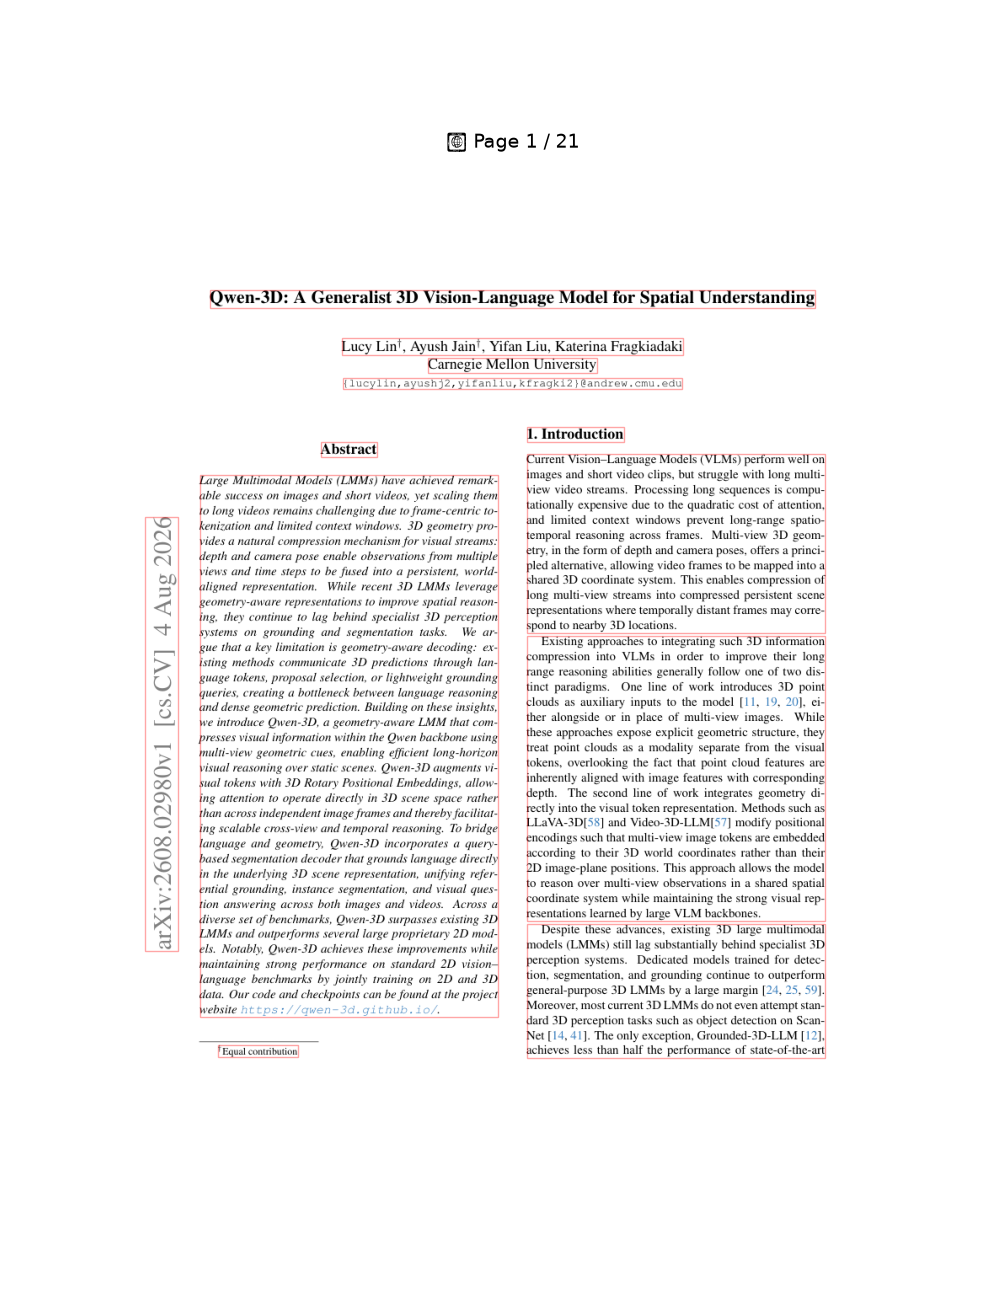

In [1]:
# ============================================================
# INTERACTIVE PDF RESEARCH READER + LOCAL OLLAMA
# ============================================================
#
# Super UI with:
#   - Dropdown to select Ollama model (auto‑populated)
#   - Refresh models button
#   - Clickable text (red) and image (blue) blocks
#   - Page slider
#   - Separate PDF, selected block, and AI response panels
#   - Selected block stays visible while AI responds
#   - Auto‑scroll chat area
#   - No double PDF view
#
# Requirements:
#   pip install pymupdf matplotlib ipympl ipywidgets requests pillow
#
# Ollama must be running: ollama serve
#
# ============================================================

%matplotlib widget

import os, io, time, json, base64, requests, traceback
import fitz
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output, HTML
from PIL import Image

# ------------------------------------------------------------
# USER CONFIGURATION
# ------------------------------------------------------------
FILE_NAME_PAPER = "../2608.02980v1.pdf"          # change to your PDF
DEFAULT_MODEL = "qwen2:0.5b"
OLLAMA_URL = "http://localhost:11434"
PDF_ZOOM = 1.5
CHAT_HEIGHT = "500px"

# ------------------------------------------------------------
# CHECK PDF
# ------------------------------------------------------------
if not os.path.exists(FILE_NAME_PAPER):
    raise FileNotFoundError(f"PDF not found: {os.path.abspath(FILE_NAME_PAPER)}")

doc = fitz.open(FILE_NAME_PAPER)
TOTAL_PAGES = len(doc)
print(f"✅ PDF loaded: {os.path.basename(FILE_NAME_PAPER)} ({TOTAL_PAGES} pages)")

# ------------------------------------------------------------
# GLOBAL STATE
# ------------------------------------------------------------
current_page_number = 1
current_blocks = []
fig = None
ax = None
chat_running = False

# ------------------------------------------------------------
# OUTPUT CONTAINERS
# ------------------------------------------------------------
# PDF viewer
pdf_output = widgets.Output(layout=widgets.Layout(width="900px", height="850px",
                                                  border="1px solid #999", overflow="auto"))

# Chat container: selected block (top) + AI response (bottom)
selected_output = widgets.Output(layout=widgets.Layout(width="100%", min_height="60px",
                                                       max_height="200px", overflow="auto",
                                                       border="1px solid #ddd"))
ai_output = widgets.Output(layout=widgets.Layout(width="100%", height=CHAT_HEIGHT,
                                                 overflow="auto", border="1px solid #ddd"))

chat_container = widgets.VBox([selected_output, ai_output],
                              layout=widgets.Layout(width="100%", height=f"calc({CHAT_HEIGHT} + 220px)",
                                                    overflow="auto"))

# ------------------------------------------------------------
# MODEL FEATURE DETECTION
# ------------------------------------------------------------
def get_model_features(model_name):
    name = model_name.lower()
    vision_keywords = ["vision", "vl", "llava", "qwen2.5vl", "qwen3-vl", "llama3.2-vision",
                       "gemma3", "ministral", "mistral-small3.1"]
    thinking_keywords = ["thinking", "reasoning", "deepseek-r1", "phi4-reasoning", "nemotron"]
    return {
        "vision": any(k in name for k in vision_keywords),
        "thinking": any(k in name for k in thinking_keywords)
    }

# ------------------------------------------------------------
# FETCH OLLAMA MODELS
# ------------------------------------------------------------
def fetch_ollama_models():
    try:
        resp = requests.get(f"{OLLAMA_URL}/api/tags", timeout=5)
        if resp.status_code == 200:
            data = resp.json()
            models = [m["name"] for m in data.get("models", [])]
            if models:
                return models
        return []
    except:
        return []

# ------------------------------------------------------------
# IMAGE TO BASE64
# ------------------------------------------------------------
def image_bytes_to_base64(img_bytes):
    return base64.b64encode(img_bytes).decode("utf-8")

# ------------------------------------------------------------
# OLLAMA CHAT (streaming) – only clears ai_output
# ------------------------------------------------------------
def chat_aware(prompt, model=None, image_b64=None):
    global chat_running
    if model is None:
        model = model_dropdown.value if model_dropdown.value else DEFAULT_MODEL
    features = get_model_features(model)
    chat_running = True

    # Clear ONLY the AI output, keep selected block visible
    with ai_output:
        clear_output(wait=True)
        display(Markdown(f"### 🤖 Ollama\n**Model:** `{model}`\n**Vision:** `{'✅' if features['vision'] else '❌'}`\n**Thinking:** `{'✅' if features['thinking'] else '❌'}`\n---\n⏳ Generating..."))

    messages = [{"role": "user", "content": prompt}]
    if image_b64 is not None:
        if not features["vision"]:
            with ai_output:
                clear_output(wait=True)
                display(Markdown(f"### ⚠️ Vision model required\n`{model}` does not support images. Use a vision model."))
            chat_running = False
            return
        messages[0]["images"] = [image_b64]

    payload = {"model": model, "messages": messages, "stream": True}
    start_time = time.time()
    thinking_text = ""
    answer_text = ""

    try:
        response = requests.post(f"{OLLAMA_URL}/api/chat", json=payload, stream=True, timeout=600)
        response.raise_for_status()

        for line in response.iter_lines():
            if not line: continue
            try:
                data = json.loads(line.decode("utf-8"))
            except:
                continue
            message = data.get("message", {})
            thinking_piece = message.get("thinking", "")
            if thinking_piece: thinking_text += thinking_piece
            content_piece = message.get("content", "")
            if content_piece: answer_text += content_piece

            with ai_output:
                clear_output(wait=True)
                md = f"### 🤖 `{model}`\n**Elapsed:** `{time.time()-start_time:.2f} sec`\n---\n"
                if thinking_text:
                    md += f"<details><summary>🧠 Thinking</summary>{thinking_text}</details>\n---\n"
                md += f"### 💡 Answer\n{answer_text}"
                display(Markdown(md))

            if data.get("done", False):
                break

        with ai_output:
            clear_output(wait=True)
            md = f"### 🤖 `{model}`\n**Time:** `{time.time()-start_time:.2f} sec`\n---\n"
            if thinking_text:
                md += f"<details><summary>🧠 Thinking</summary>{thinking_text}</details>\n---\n"
            md += f"### 💡 Answer\n{answer_text}"
            display(Markdown(md))

    except Exception as e:
        with ai_output:
            clear_output(wait=True)
            display(Markdown(f"### ❌ Error\n```text\n{type(e).__name__}: {e}\n```"))
            traceback.print_exc()
    finally:
        chat_running = False
        # Scroll to bottom of chat container (simple JS)
        display(HTML("<script>var el = document.querySelector('.jupyter-widgets-output-area'); if(el) el.scrollTop = el.scrollHeight;</script>"))

# ------------------------------------------------------------
# EXTRACT PDF BLOCKS (text + image) using get_text("dict")
# ------------------------------------------------------------
def get_pdf_blocks(page):
    data = page.get_text("dict")
    blocks = []
    for idx, block in enumerate(data.get("blocks", [])):
        bbox = block.get("bbox")
        if not bbox: continue
        typ = block.get("type")
        if typ == 0:   # text
            text_parts = []
            for line in block.get("lines", []):
                for span in line.get("spans", []):
                    t = span.get("text", "")
                    if t: text_parts.append(t)
            text = " ".join(text_parts).strip()
            if text:
                blocks.append({"type": "text", "bbox": bbox, "text": text, "block_index": idx})
        elif typ == 1: # image
            img_bytes = block.get("image")
            if img_bytes:
                blocks.append({"type": "image", "bbox": bbox, "image": img_bytes,
                               "block_index": idx})
    return blocks

# ------------------------------------------------------------
# COORDINATE CONVERSION (PDF coords → display coords, no flip)
# Since imshow(origin='upper'), y increases downward as in PDF.
# ------------------------------------------------------------
def pdf_bbox_to_display_bbox(bbox, zoom):
    x0, y0, x1, y1 = bbox
    return (x0*zoom, y0*zoom, (x1-x0)*zoom, (y1-y0)*zoom)

# ------------------------------------------------------------
# PROMPT BUILDERS
# ------------------------------------------------------------
def create_text_prompt(text, page_number):
    return f"""
You are helping me understand a research paper. I clicked a text block from page {page_number}.

Explain the selected text clearly. Structure your answer:
1. 📌 What the paragraph says
2. 🧠 Simple explanation
3. 🔬 Technical meaning
4. 📐 Explain equations/concepts
5. 🧩 Important terminology
6. 💡 Why important
7. 🔗 How it connects to the paper
8. 📝 Give a small example if useful

Selected text:
---
{text}
---
"""

def create_image_prompt(page_number):
    return f"""
You are helping me understand a research paper. I clicked an image/figure from page {page_number}.

Analyze the image. Explain:
1. 🖼️ What is shown?
2. 🧩 Major components
3. ➡️ Arrows and flow
4. 📦 Each block/module
5. 📐 Axes, plots, equations
6. 🔬 Technical architecture
7. 🧠 Simple language
8. 🔗 How it relates to the paper
9. 💡 Main idea the authors want to convey
10. 📝 Give a simple example/analogy if useful.

Do not invent information not visible. If text is unreadable, say so.
"""

# ------------------------------------------------------------
# CLICK HANDLERS – show selected block in selected_output, then call AI
# ------------------------------------------------------------
def handle_text_block(block):
    text = block["text"]
    pnum = current_page_number
    # Show selected text in the selected_output (and keep it)
    with selected_output:
        clear_output(wait=True)
        display(Markdown(f"## 📄 Selected Text\n**Page:** `{pnum}`\n---\n{text}\n---\n"))
    # Now send to AI (will stream in ai_output)
    chat_aware(create_text_prompt(text, pnum), model=model_dropdown.value)

def handle_image_block(block):
    pnum = current_page_number
    model = model_dropdown.value
    if not get_model_features(model)["vision"]:
        with selected_output:
            clear_output(wait=True)
            display(Markdown(f"## 🖼️ Image selected\n**Page:** `{pnum}`\n### ⚠️ `{model}` is not a vision model. Select a vision model."))
        return
    img_bytes = block.get("image")
    if not img_bytes:
        with selected_output:
            clear_output(wait=True)
            display(Markdown("### ❌ Could not extract image."))
        return
    image_b64 = image_bytes_to_base64(img_bytes)
    # Show image preview in selected_output
    with selected_output:
        clear_output(wait=True)
        display(Markdown(f"## 🖼️ Selected Figure\n**Page:** `{pnum}`"))
        try:
            im = Image.open(io.BytesIO(img_bytes))
            display(im)
        except:
            display(Markdown("*Image preview not available*"))
    # Send to vision model
    chat_aware(create_image_prompt(pnum), model=model, image_b64=image_b64)

# ------------------------------------------------------------
# MOUSE CLICK (manual hit test)
# ------------------------------------------------------------
def on_mouse_click(event):
    if event.inaxes != ax or event.xdata is None or event.ydata is None:
        return
    if ax is None:
        return
    click_x, click_y = event.xdata, event.ydata
    zoom = PDF_ZOOM
    for block in current_blocks:
        x, y, w, h = pdf_bbox_to_display_bbox(block["bbox"], zoom)
        if x <= click_x <= x+w and y <= click_y <= y+h:
            if block["type"] == "text":
                handle_text_block(block)
            else:
                handle_image_block(block)
            return

# ------------------------------------------------------------
# RENDER PAGE
# ------------------------------------------------------------
def render_page(page_number):
    global fig, ax, current_blocks, current_page_number
    current_page_number = page_number
    page = doc[page_number-1]
    current_blocks = get_pdf_blocks(page)

    zoom = PDF_ZOOM
    matrix = fitz.Matrix(zoom, zoom)
    pix = page.get_pixmap(matrix=matrix, alpha=False)
    img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)

    if fig is None:
        fig, ax = plt.subplots(figsize=(10, 13))
        fig.canvas.mpl_connect("button_press_event", on_mouse_click)
    else:
        ax.clear()

    ax.imshow(img, origin="upper")
    ax.set_xlim(0, pix.width)
    ax.set_ylim(pix.height, 0)
    ax.axis("off")
    ax.set_title(f"📄 Page {page_number} / {TOTAL_PAGES}", fontsize=14)

    for block in current_blocks:
        x, y, w, h = pdf_bbox_to_display_bbox(block["bbox"], zoom)
        color = "red" if block["type"] == "text" else "blue"
        alpha = 0.35 if block["type"] == "text" else 0.6
        lw = 1.0 if block["type"] == "text" else 2.0
        rect = patches.Rectangle((x, y), w, h, fill=False,
                                 linewidth=lw, edgecolor=color, alpha=alpha)
        ax.add_patch(rect)

    fig.canvas.draw_idle()

# ------------------------------------------------------------
# UPDATE PAGE (slider callback)
# ------------------------------------------------------------
def update_page(change=None):
    pnum = change["new"] if change else page_slider.value
    render_page(int(pnum))
    page_status.value = f"<b>📄 Page {pnum} / {TOTAL_PAGES}</b>"

# ------------------------------------------------------------
# REFRESH MODELS
# ------------------------------------------------------------
def refresh_models(change=None):
    models = fetch_ollama_models()
    if not models:
        models = ["No models found – check Ollama"]
    model_dropdown.options = models
    if DEFAULT_MODEL in models:
        model_dropdown.value = DEFAULT_MODEL
    elif models:
        model_dropdown.value = models[0]
    update_model_info()

# ------------------------------------------------------------
# UPDATE MODEL INFO
# ------------------------------------------------------------
def update_model_info(change=None):
    m = model_dropdown.value
    if m and m != "No models found – check Ollama":
        f = get_model_features(m)
        model_info.value = f"<b>Model:</b> {m} &nbsp;&nbsp; <b>{'✅ Vision' if f['vision'] else '❌ Text only'}</b> &nbsp;&nbsp; <b>{'🧠 Thinking' if f['thinking'] else '💬 Normal'}</b>"
    else:
        model_info.value = ""

# ------------------------------------------------------------
# WIDGETS
# ------------------------------------------------------------
# Page slider
page_slider = widgets.IntSlider(value=1, min=1, max=TOTAL_PAGES, step=1,
                                description="Page:", continuous_update=False,
                                layout=widgets.Layout(width="700px"))
page_slider.observe(update_page, names="value")

# Model dropdown
model_dropdown = widgets.Dropdown(
    options=["Loading models..."],
    value="Loading models...",
    description="Model:",
    layout=widgets.Layout(width="400px")
)

# Refresh button
refresh_button = widgets.Button(
    description="↻ Refresh Models",
    button_style="info",
    layout=widgets.Layout(width="150px")
)
refresh_button.on_click(refresh_models)

# Model info display
model_info = widgets.HTML()

# Page status
page_status = widgets.HTML(value="<b>📄 Page 1</b>")

# Instructions
instructions = widgets.HTML("""
<div style="padding:10px; border:1px solid #aaa; border-radius:6px; margin-bottom:10px; background:#f9f9f9;">
<b>🖱️ How to use:</b>
<ul>
<li><b>Red rectangle</b> → click to explain text</li>
<li><b>Blue rectangle</b> → click to analyze figure (vision model required)</li>
<li>Select an Ollama model from the dropdown</li>
<li>Use slider to navigate</li>
</ul>
</div>
""")

# Headers
pdf_header = widgets.HTML("<h2>📚 Interactive Research Paper Reader</h2>")
ai_header = widgets.HTML("<h2>🤖 AI Research Assistant</h2>")

# Controls row
controls_row = widgets.HBox([
    page_slider,
    widgets.VBox([model_dropdown, refresh_button]),
    model_info,
    page_status
], layout=widgets.Layout(align_items="center", justify_content="space-between"))

# ------------------------------------------------------------
# BUILD APPLICATION
# ------------------------------------------------------------
application = widgets.VBox([
    pdf_header,
    instructions,
    controls_row,
    widgets.HTML("<h3>📄 PDF</h3>"),
    pdf_output,
    ai_header,
    chat_container
], layout=widgets.Layout(width="950px"))

# ------------------------------------------------------------
# DISPLAY AND INITIALIZE
# ------------------------------------------------------------
display(application)

# Load models
refresh_models()

# Render first page
render_page(1)

# Show canvas in the PDF output (only once)
with pdf_output:
    clear_output(wait=True)
    display(fig.canvas)

# Update UI
update_model_info()
page_status.value = f"<b>📄 Page 1 / {TOTAL_PAGES}</b>"

print("✅ Interactive PDF reader ready.")
print("🖱️ Click a red text block or blue image block.")

In [ ]:
# Call chat
prompt = "Explain the difference between a research hypothesis, a mathematical model, and a simulation model."
chat_aware(prompt, model="qwen3:0.6b")